# One-Period Debt with Sunspots and LOLR

This notebook is a short and simple implementation of the model in `docs/LOLR_oneperioddebt_vsunspot.pdf`.

- State: private debt `b`, LOLR debt `l`, growth `g`, sunspot `s`, shock `eps`.
- Choice in repayment: next private debt `b'` and next LOLR debt `l'`.
- Choice in default: next LOLR debt `l'` only.

The code is intentionally compact. The bad-sunspot schedule uses a simple upper-envelope filter, which keeps the implementation readable.

In [18]:
using Statistics
include("src/simple_s_lolr.jl")
Threads.nthreads()

8

In [19]:
# Small baseline so the notebook runs quickly.
# Set LOLR borrowing to zero by collapsing the l-grid to {0}.
model = init_model(Model(Nb = 400, Nl = 20, Ne = 5, Δ_nd = 0.05, Δ_d = 0.05))
model.max_iter = 50
model.max_iter_vd = 25
model.max_iter_x = 40
model.pub = 0.65
model

Model(400, 20, 2, 2, 5, -0.05, 1.0, 0.0, 0.06, [-0.05, -0.04736842105263158, -0.04473684210526316, -0.042105263157894736, -0.039473684210526314, -0.03684210526315789, -0.034210526315789476, -0.031578947368421054, -0.02894736842105263, -0.02631578947368421  …  0.9763157894736842, 0.9789473684210527, 0.9815789473684211, 0.9842105263157894, 0.9868421052631579, 0.9894736842105263, 0.9921052631578947, 0.9947368421052631, 0.9973684210526316, 1.0], [0.0, 0.003157894736842105, 0.00631578947368421, 0.009473684210526316, 0.01263157894736842, 0.015789473684210527, 0.018947368421052633, 0.022105263157894735, 0.02526315789473684, 0.028421052631578948, 0.031578947368421054, 0.034736842105263156, 0.037894736842105266, 0.04105263157894737, 0.04421052631578947, 0.04736842105263158, 0.05052631578947368, 0.05368421052631579, 0.056842105263157895, 0.06], [0.96, 1.04], [-2.5, -1.25, 0.0, 1.25, 2.5], [0.6 0.4; 0.25 0.75], [0.25 0.75; 0.25 0.75], [0.030396361765261396, 0.2355891672834392, 0.4680289419025988,

In [20]:
# Time the main steps inside solve_model.
function time_solve_steps(model; n_iter = min(1, model.max_iter))
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]

    vnd = copy(sol.vnd)
    vd = copy(sol.vd)
    X = copy(sol.X)
    d = copy(sol.d)
    e = copy(sol.e)
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    R = copy(sol.R)
    n = copy(sol.n)
    pdefault = copy(sol.pdefault)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)
    l_policy_idx_d = copy(sol.l_policy_idx_d)

    t_vd = 0.0
    t_default = 0.0
    t_prices = 0.0
    t_schedule = 0.0
    t_mask = 0.0
    t_vnd = 0.0

    for it in 1:n_iter
        damp = max(0.05, 0.9 - 0.0 * ((it - 1) / 10))

        t_vd += @elapsed begin
            vd_err, l_policy_idx_d = _solve_vd!(vd, vnd, model, y, g_beta, bprime_idx, kbprime_idx)
        end

        t_default += @elapsed begin
            d = vnd .< vd
            e = .!d
        end

        t_prices += @elapsed begin
            Q, x_err = _solve_prices!(X, d, e, model, bprime_idx, kbprime_idx, l_policy_idx_d)
        end

        t_schedule += @elapsed begin
            _compute_schedule!(QE, R, n, pdefault, model, Q, d, gb, QE_tmp, pdefault_tmp)
        end

        t_mask += @elapsed begin
            schedule_mask = _select_schedule_mask(n, R, pdefault, model)
        end

        t_vnd += @elapsed begin
            err = _update_vnd!(vnd, vd, model, y, g_beta, n, pdefault, schedule_mask, b0_idx, l0_idx; damp = damp)
        end

        println("iter=", it, ", vnd_err=", err, ", vd_err=", vd_err, ", x_err=", x_err)
    end

    println()
    println("Timing over ", n_iter, " outer iterations")
    println("  solve_vd:        ", round(t_vd, digits = 3), " s")
    println("  default_reentry: ", round(t_default, digits = 3), " s")
    println("  solve_prices:    ", round(t_prices, digits = 3), " s")
    println("  compute_schedule:", round(t_schedule, digits = 3), " s")
    println("  select_mask:     ", round(t_mask, digits = 3), " s")
    println("  update_vnd:      ", round(t_vnd, digits = 3), " s")
    return nothing
end

time_solve_steps(model)


iter=1, vnd_err=1.734101144678685, vd_err=5.099850426404373e-7, x_err=0.0001480044349380094

Timing over 1 outer iterations
  solve_vd:        0.149 s
  default_reentry: 0.0 s
  solve_prices:    0.563 s
  compute_schedule:0.0 s
  select_mask:     0.002 s
  update_vnd:      2.014 s


## Step-by-Step Diagnostics

These cells mimic the steps inside `solve_model`, one block at a time. Run them in order to see which block looks wrong before the full outer fixed point is used.

In [21]:
using Plots

function make_debug_state(model)
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)

    return Dict{Symbol, Any}(
        :vnd => copy(sol.vnd),
        :vd => copy(sol.vd),
        :X => copy(sol.X),
        :Q => copy(sol.Q),
        :d => copy(sol.d),
        :e => copy(sol.e),
        :R => copy(sol.R),
        :n => copy(sol.n),
        :pdefault => copy(sol.pdefault),
        :schedule_mask => copy(sol.schedule_mask),
        :l_policy_idx_d => copy(sol.l_policy_idx_d),
        :QE => QE,
        :QE_tmp => QE_tmp,
        :pdefault_tmp => pdefault_tmp,
        :y => y,
        :g_beta => g_beta,
        :gb => gb,
        :bprime_idx => bprime_idx,
        :kbprime_idx => kbprime_idx,
        :b0_idx => b0_idx,
        :l0_idx => l0_idx,
    )
end

dbg = make_debug_state(model)
e_idx = cld(model.Ne, 2)
l_idx = 1
gi = 1
s_bad = 1
s_good = min(2, model.Ns)

println("Debug state ready.")
println("Use gi=", gi, ", l_idx=", l_idx, ", e_idx=", e_idx)


Debug state ready.
Use gi=1, l_idx=1, e_idx=3


vd_err = 5.099850426404373e-7


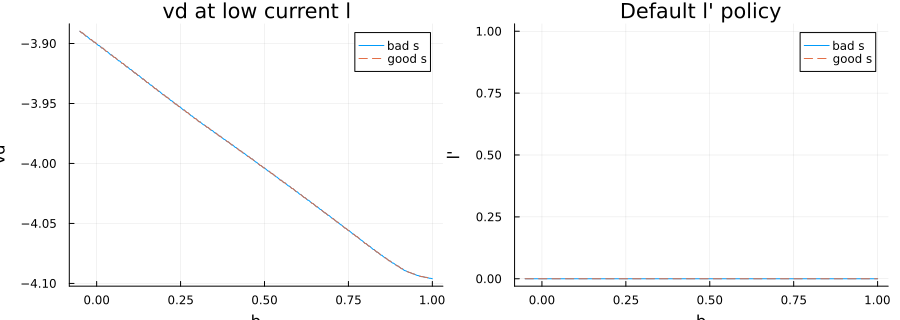

In [22]:
# Step 2: solve vd given current vnd.
vd_err, dbg[:l_policy_idx_d] = _solve_vd!(dbg[:vd], dbg[:vnd], model, dbg[:y], dbg[:g_beta], dbg[:bprime_idx], dbg[:kbprime_idx])
println("vd_err = ", vd_err)

p1 = plot(model.b, dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vd", title = "vd at low current l")
plot!(p1, model.b, dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_bad, e_idx]], label = "bad s", xlabel = "b", ylabel = "l'", title = "Default l' policy")
plot!(p2, model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_good, e_idx]], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Mean default probability in grid = 0.6753625


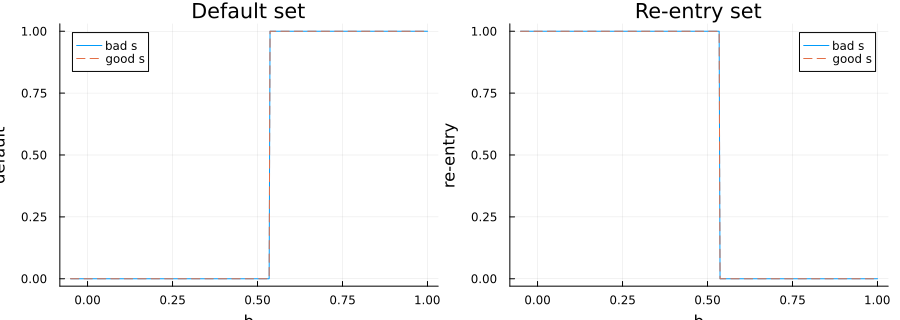

In [23]:
# Step 3: default and re-entry from vnd and vd.
dbg[:d] = dbg[:vnd] .< dbg[:vd]
dbg[:e] = .!dbg[:d]
println("Mean default probability in grid = ", mean(dbg[:d]))

p1 = plot(model.b, Float64.(dbg[:d][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "default", title = "Default set")
plot!(p1, model.b, Float64.(dbg[:d][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

p2 = plot(model.b, Float64.(dbg[:e][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "re-entry", title = "Re-entry set")
plot!(p2, model.b, Float64.(dbg[:e][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


x_err = 0.0001480044349380094


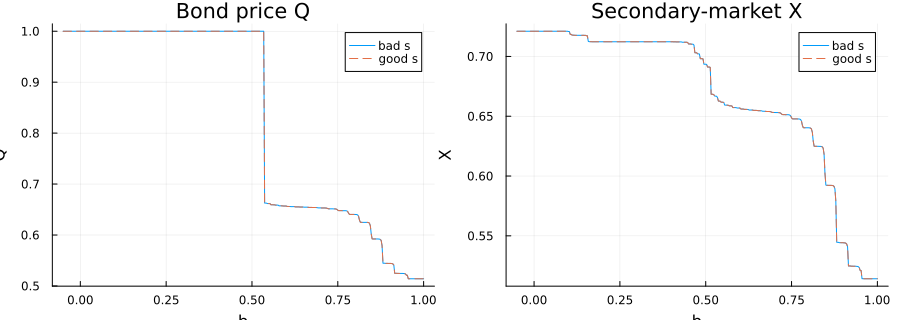

In [24]:
# Step 4: solve prices Q and X given d, e, and default l' policy.
dbg[:Q], x_err = _solve_prices!(dbg[:X], dbg[:d], dbg[:e], model, dbg[:bprime_idx], dbg[:kbprime_idx], dbg[:l_policy_idx_d])
println("x_err = ", x_err)

p1 = plot(model.b, dbg[:Q][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "Q", title = "Bond price Q")
plot!(p1, model.b, dbg[:Q][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, dbg[:X][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "X", title = "Secondary-market X")
plot!(p2, model.b, dbg[:X][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Bad-sunspot available points = 7942
Good-sunspot available points = 8000


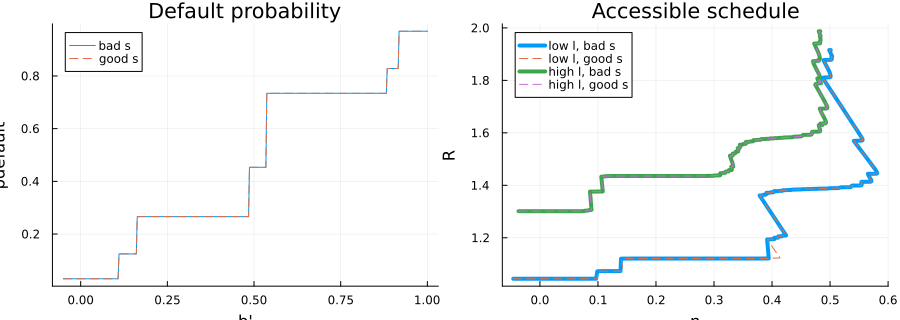

In [25]:
# Step 5: schedules and sunspot mask given Q and d.
_compute_schedule!(dbg[:QE], dbg[:R], dbg[:n], dbg[:pdefault], model, dbg[:Q], dbg[:d], dbg[:gb], dbg[:QE_tmp], dbg[:pdefault_tmp])
dbg[:schedule_mask] = _select_schedule_mask(dbg[:n], dbg[:R], dbg[:pdefault], model)

mask_bad = dbg[:schedule_mask][:, :, gi, s_bad]
mask_good = dbg[:schedule_mask][:, :, gi, s_good]
println("Bad-sunspot available points = ", count(mask_bad))
println("Good-sunspot available points = ", count(mask_good))
l_low = 1
l_high = model.Nl

function masked_line(x, y, mask)
    return x,y
end

p1 = plot(model.b, dbg[:pdefault][:, l_idx, gi, s_bad], label = "bad s", xlabel = "b'", ylabel = "pdefault", title = "Default probability")
plot!(p1, model.b, dbg[:pdefault][:, l_idx, gi, s_good], label = "good s", linestyle = :dash)

mask_bad_low = dbg[:schedule_mask][:, l_low, gi, s_bad]
mask_good_low = dbg[:schedule_mask][:, l_low, gi, s_good]
mask_bad_high = dbg[:schedule_mask][:, l_high, gi, s_bad]
mask_good_high = dbg[:schedule_mask][:, l_high, gi, s_good]

n_bad_low = dbg[:n][mask_bad_low, l_low, gi, s_bad]
R_bad_low = dbg[:R][mask_bad_low, l_low, gi, s_bad]
n_good_low = dbg[:n][mask_good_low, l_low, gi, s_good]
R_good_low = dbg[:R][mask_good_low, l_low, gi, s_good]
n_bad_high = dbg[:n][mask_bad_high, l_high, gi, s_bad]
R_bad_high = dbg[:R][mask_bad_high, l_high, gi, s_bad]
n_good_high = dbg[:n][mask_good_high, l_high, gi, s_good]
R_good_high = dbg[:R][mask_good_high, l_high, gi, s_good]

p2 = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "n", ylabel = "R", title = "Accessible schedule", linewidth = 4)
plot!(p2, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p2, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 4)
plot!(p2, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Final vnd_err = 1.734101144678685


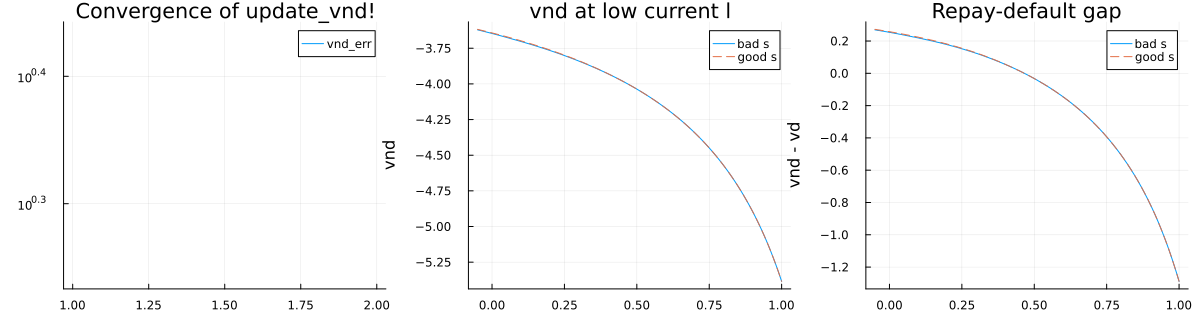

In [26]:
# Step 6: update vnd given the current schedules, jusdt one iteration to check the error and convergence. The full iteration is done in time_solve_steps.
vnd_errs = Float64[]
for it in 1:1
    err = _update_vnd!(dbg[:vnd], dbg[:vd], model, dbg[:y], dbg[:g_beta], dbg[:n], dbg[:pdefault], dbg[:schedule_mask], dbg[:b0_idx], dbg[:l0_idx]; damp = 0.9)
    push!(vnd_errs, err)
    err < model.tol && break
end
println("Final vnd_err = ", last(vnd_errs))

p1 = plot(vnd_errs, yscale = :log10, xlabel = "step-6 iteration", ylabel = "error", label = "vnd_err", title = "Convergence of update_vnd!")

p2 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd", title = "vnd at low current l")
plot!(p2, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p3 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx] .- dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd - vd", title = "Repay-default gap")
plot!(p3, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx] .- dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, p3, layout = (1, 3), size = (1200, 320))


In [27]:
sol = solve_model(model; verbose = true)
println("Mean default probability in the state grid = ", mean(sol.d))
println("Final outer error = ", sol.outer_errs[end])

iter=1, vnd_err=1.734101144678685, vd_err=5.099850426404373e-7, x_err=0.0001480044349380094, damp=0.9
iter=2, vnd_err=2.0714651629565015, vd_err=9.425678388907954e-7, x_err=0.00474389382592047, damp=0.9
iter=3, vnd_err=0.7088184142807208, vd_err=7.820316145767947e-7, x_err=0.0007969496217896666, damp=0.9
iter=4, vnd_err=0.23597190373930133, vd_err=7.115783775546447e-7, x_err=0.0004065181552385666, damp=0.9
iter=5, vnd_err=0.2739240507920142, vd_err=8.853719544177352e-7, x_err=0.0005277549948631555, damp=0.9
iter=6, vnd_err=0.2456585808657863, vd_err=8.345680981847181e-7, x_err=0.0005046423694697599, damp=0.9
iter=7, vnd_err=0.14400435426208613, vd_err=7.27043492076973e-7, x_err=0.0004661505009858069, damp=0.9
iter=8, vnd_err=0.12785908977490745, vd_err=8.72418689290555e-7, x_err=0.00039119944993640243, damp=0.9
iter=9, vnd_err=0.12070150862445228, vd_err=7.598920674922738e-7, x_err=0.00036390809827602233, damp=0.9
iter=10, vnd_err=0.08966534933870474, vd_err=9.384702437387205e-7, x_err

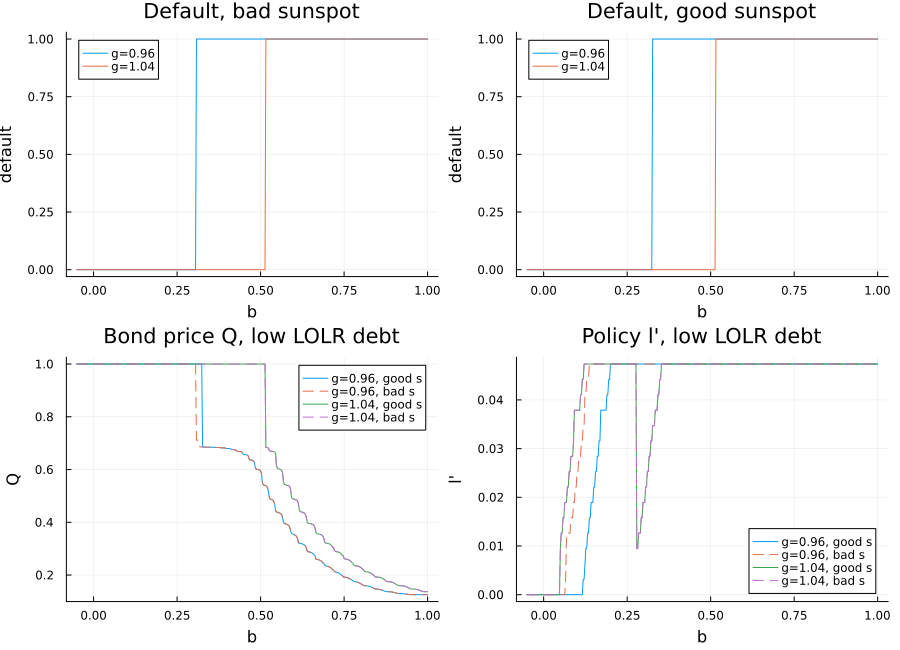

In [28]:
using Plots

b = model.b
l = model.l
g = model.g
e_idx = cld(model.Ne, 2)
l_idx = 1
s_bad = 1
s_good = 2

p1 = plot(title = "Default, bad sunspot", xlabel = "b", ylabel = "default")
p2 = plot(title = "Default, good sunspot", xlabel = "b", ylabel = "default")
p3 = plot(title = "Bond price Q, low LOLR debt", xlabel = "b", ylabel = "Q")
p4 = plot(title = "Policy l', low LOLR debt", xlabel = "b", ylabel = "l'")

for gi in 1:model.Ng
    plot!(p1, b, Float64.(sol.d[:, l_idx, gi, s_bad, e_idx]), label = "g=$(g[gi])")
    plot!(p2, b, Float64.(sol.d[:, l_idx, gi, s_good, e_idx]), label = "g=$(g[gi])")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_good, e_idx], label = "g=$(g[gi]), good s")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_bad, e_idx], linestyle = :dash, label = "g=$(g[gi]), bad s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_good, e_idx]], label = "g=$(g[gi]), good s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_bad, e_idx]], linestyle = :dash, label = "g=$(g[gi]), bad s")
end

plot(p1, p2, p3, p4, layout = (2, 2), size = (900, 650))

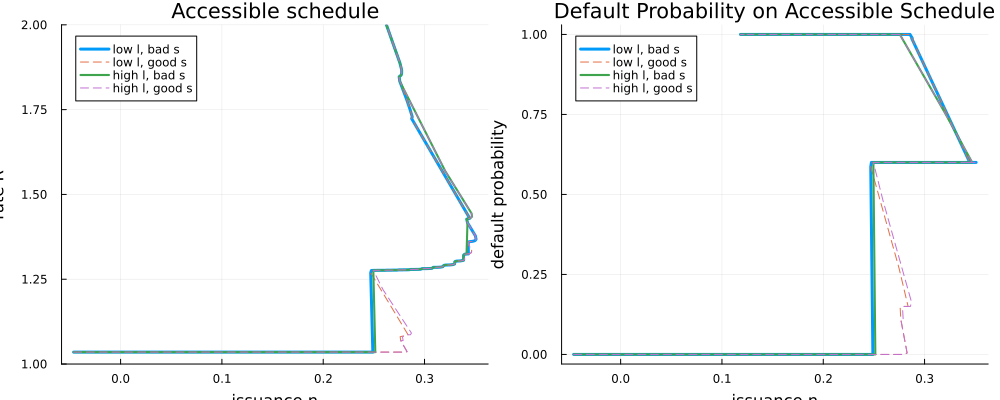

In [29]:
# Compare the available schedule lines for low and high l'.
gi = 1
l_low = 1
l_high = 10

mask_bad_low = sol.schedule_mask[:, l_low, gi, s_bad]
mask_good_low = sol.schedule_mask[:, l_low, gi, s_good]
mask_bad_high = sol.schedule_mask[:, l_high, gi, s_bad]
mask_good_high = sol.schedule_mask[:, l_high, gi, s_good]

n_bad_low = sol.n[mask_bad_low, l_low, gi, s_bad]
R_bad_low = sol.R[mask_bad_low, l_low, gi, s_bad]
n_good_low = sol.n[mask_good_low, l_low, gi, s_good]
R_good_low = sol.R[mask_good_low, l_low, gi, s_good]
n_bad_high = sol.n[mask_bad_high, l_high, gi, s_bad]
R_bad_high = sol.R[mask_bad_high, l_high, gi, s_bad]
n_good_high = sol.n[mask_good_high, l_high, gi, s_good]
R_good_high = sol.R[mask_good_high, l_high, gi, s_good]

n_bad_low_pd = sol.n[mask_bad_low, l_low, gi, s_bad]
p_bad_low = sol.pdefault[mask_bad_low, l_low, gi, s_bad]
n_good_low_pd = sol.n[mask_good_low, l_low, gi, s_good]
p_good_low = sol.pdefault[mask_good_low, l_low, gi, s_good]
n_bad_high_pd = sol.n[mask_bad_high, l_high, gi, s_bad]
p_bad_high = sol.pdefault[mask_bad_high, l_high, gi, s_bad]
n_good_high_pd = sol.n[mask_good_high, l_high, gi, s_good]
p_good_high = sol.pdefault[mask_good_high, l_high, gi, s_good]

p_sched = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "rate R", title = "Accessible schedule", linewidth = 3,ylims=(1.0, 2.0))
plot!(p_sched, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_sched, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_sched, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

p_def = plot(n_bad_low_pd, p_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "default probability", title = "Default Probability on Accessible Schedule", linewidth = 3)
plot!(p_def, n_good_low_pd, p_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_def, n_bad_high_pd, p_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_def, n_good_high_pd, p_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p_sched, p_def, layout = (1, 2), size = (1000, 400))

## Comparative Statics: LOLR Quantity and LOLR Spread

These cells sweep a common LOLR quantity limit `Δ_nd = Δ_d = Δ` over `0.01, 0.02, 0.03, 0.04, 0.05` and set the LOLR gross rate to `R_l = 1 + r^* + σ` for `σ \in \{0.04, 0.06, 0.08, 0.10\}`.

The computation is separated from the plotting cells so the model grid only needs to be solved once.

In [30]:
delta_grid = [0.01, 0.02, 0.03, 0.04, 0.05]
sigma_grid = [0.04, 0.06, 0.08, 0.10]

# Use a smaller baseline than the detailed diagnostics so the sweep remains tractable.
grid_base_model = init_model(Model(Nb = 200, Nl = 15, Ne = 5))
grid_base_model.max_iter = 40
grid_base_model.max_iter_vd = 20
grid_base_model.max_iter_x = 35
grid_base_model.pub = 0.65

function make_grid_model(base_model, Δ, σ)
    return init_model(Model(
        Nb = base_model.Nb,
        Nl = base_model.Nl,
        Ne = base_model.Ne,
        b_min = base_model.b_min,
        b_max = base_model.b_max,
        l_min = base_model.l_min,
        l_max = base_model.l_max,
        g = copy(base_model.g),
        P_g = copy(base_model.P_g),
        P_s = copy(base_model.P_s),
        beta = base_model.beta,
        gamma = base_model.gamma,
        sigma_eps = base_model.sigma_eps,
        n_std = base_model.n_std,
        rstar = base_model.rstar,
        theta = base_model.theta,
        kappa = base_model.kappa,
        phi_g = copy(base_model.phi_g),
        nbar_g = copy(base_model.nbar_g),
        R_l_nd = 1 + base_model.rstar + σ,
        R_l_d = 1 + base_model.rstar + σ,
        Δ_nd = Δ,
        Δ_d = Δ,
        pub = base_model.pub,
        max_iter = base_model.max_iter,
        max_iter_vd = base_model.max_iter_vd,
        max_iter_x = base_model.max_iter_x,
        tol = base_model.tol,
        tol_vd = base_model.tol_vd,
        tol_x = base_model.tol_x,
    ))
end

function summarize_grid_solution(model, sol)
    s_bad = 1
    bad_mask = sol.schedule_mask[:, :, :, s_bad]
    R_bad = sol.R[:, :, :, s_bad][bad_mask]
    p_bad = sol.pdefault[:, :, :, s_bad][bad_mask]
    return (
        default_share = mean(sol.d),
        mean_l_repay = mean(model.l[sol.l_policy_idx]),
        mean_l_default = mean(model.l[sol.l_policy_idx_d]),
        mean_R_bad = isempty(R_bad) ? NaN : mean(R_bad),
        mean_p_bad = isempty(p_bad) ? NaN : mean(p_bad),
        max_l = maximum(model.l),
    )
end

function metric_matrix(summary_grid, key)
    return [getfield(summary_grid[i, j], key) for i in axes(summary_grid, 1), j in axes(summary_grid, 2)]
end

(delta_grid = delta_grid, sigma_grid = sigma_grid, grid_base_model = grid_base_model)


(delta_grid = [0.01, 0.02, 0.03, 0.04, 0.05], sigma_grid = [0.04, 0.06, 0.08, 0.1], grid_base_model = Model(200, 15, 2, 2, 5, -0.05, 1.0, 0.0, 0.06, [-0.05, -0.04472361809045226, -0.039447236180904524, -0.034170854271356785, -0.028894472361809045, -0.023618090452261306, -0.018341708542713567, -0.01306532663316583, -0.007788944723618091, -0.002512562814070352  …  0.9525125628140704, 0.9577889447236181, 0.9630653266331658, 0.9683417085427136, 0.9736180904522613, 0.978894472361809, 0.9841708542713568, 0.9894472361809046, 0.9947236180904523, 1.0], [0.0, 0.004285714285714286, 0.008571428571428572, 0.012857142857142857, 0.017142857142857144, 0.02142857142857143, 0.025714285714285714, 0.03, 0.03428571428571429, 0.03857142857142857, 0.04285714285714286, 0.047142857142857146, 0.05142857142857143, 0.055714285714285716, 0.06], [0.96, 1.04], [-2.5, -1.25, 0.0, 1.25, 2.5], [0.6 0.4; 0.25 0.75], [0.25 0.75; 0.25 0.75], [0.030396361765261396, 0.2355891672834392, 0.4680289419025988, 0.2355891672834392

In [31]:
grid_models = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))
grid_solutions = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))
grid_summary = Matrix{Any}(undef, length(delta_grid), length(sigma_grid))

for (j, σ) in enumerate(sigma_grid)
    warm_sol = nothing
    for (i, Δ) in enumerate(delta_grid)
        m = make_grid_model(grid_base_model, Δ, σ)
        sol_Δσ = solve_model(m; sol = warm_sol, verbose = false)
        grid_models[i, j] = m
        grid_solutions[i, j] = sol_Δσ
        grid_summary[i, j] = summarize_grid_solution(m, sol_Δσ)
        warm_sol = sol_Δσ
        println("solved Δ=", Δ, ", σ=", σ,
            ", default_share=", round(grid_summary[i, j].default_share, digits = 4),
            ", mean_l'=", round(grid_summary[i, j].mean_l_repay, digits = 4))
    end
end

grid_results = (
    delta_grid = delta_grid,
    sigma_grid = sigma_grid,
    models = grid_models,
    solutions = grid_solutions,
    summary = grid_summary,
)

[merge((Δ = delta_grid[i], σ = sigma_grid[j]), grid_summary[i, j]) for i in eachindex(delta_grid), j in eachindex(sigma_grid)]


solved Δ=0.01, σ=0.04, default_share=0.5477, mean_l'=0.0075
solved Δ=0.02, σ=0.04, default_share=0.5488, mean_l'=0.0149
solved Δ=0.03, σ=0.04, default_share=0.5504, mean_l'=0.0261
solved Δ=0.04, σ=0.04, default_share=0.5512, mean_l'=0.0337
solved Δ=0.05, σ=0.04, default_share=0.5521, mean_l'=0.0412
solved Δ=0.01, σ=0.06, default_share=0.5477, mean_l'=0.0073
solved Δ=0.02, σ=0.06, default_share=0.5488, mean_l'=0.0146
solved Δ=0.03, σ=0.06, default_share=0.5504, mean_l'=0.0256
solved Δ=0.04, σ=0.06, default_share=0.5512, mean_l'=0.0329
solved Δ=0.05, σ=0.06, default_share=0.5521, mean_l'=0.0404
solved Δ=0.01, σ=0.08, default_share=0.5477, mean_l'=0.0071
solved Δ=0.02, σ=0.08, default_share=0.5489, mean_l'=0.0141
solved Δ=0.03, σ=0.08, default_share=0.5504, mean_l'=0.0247
solved Δ=0.04, σ=0.08, default_share=0.5512, mean_l'=0.0319
solved Δ=0.05, σ=0.08, default_share=0.5521, mean_l'=0.0392
solved Δ=0.01, σ=0.1, default_share=0.5478, mean_l'=0.0069
solved Δ=0.02, σ=0.1, default_share=0.548

5×4 Matrix{NamedTuple{(:Δ, :σ, :default_share, :mean_l_repay, :mean_l_default, :mean_R_bad, :mean_p_bad, :max_l), NTuple{8, Float64}}}:
 (Δ = 0.01, σ = 0.04, default_share = 0.5477, mean_l_repay = 0.00745207, mean_l_default = 0.00857143, mean_R_bad = 2.85478, mean_p_bad = 0.546798, max_l = 0.06)  …  (Δ = 0.01, σ = 0.1, default_share = 0.54775, mean_l_repay = 0.00694929, mean_l_default = 0.00855486, mean_R_bad = 2.8548, mean_p_bad = 0.546828, max_l = 0.06)
 (Δ = 0.02, σ = 0.04, default_share = 0.54885, mean_l_repay = 0.0149084, mean_l_default = 0.0171419, mean_R_bad = 2.85461, mean_p_bad = 0.548163, max_l = 0.06)      (Δ = 0.02, σ = 0.1, default_share = 0.548867, mean_l_repay = 0.0138234, mean_l_default = 0.0170961, mean_R_bad = 2.85462, mean_p_bad = 0.548186, max_l = 0.06)
 (Δ = 0.03, σ = 0.04, default_share = 0.550383, mean_l_repay = 0.0261444, mean_l_default = 0.0299891, mean_R_bad = 2.85231, mean_p_bad = 0.549427, max_l = 0.06)     (Δ = 0.03, σ = 0.1, default_share = 0.550417, mean_

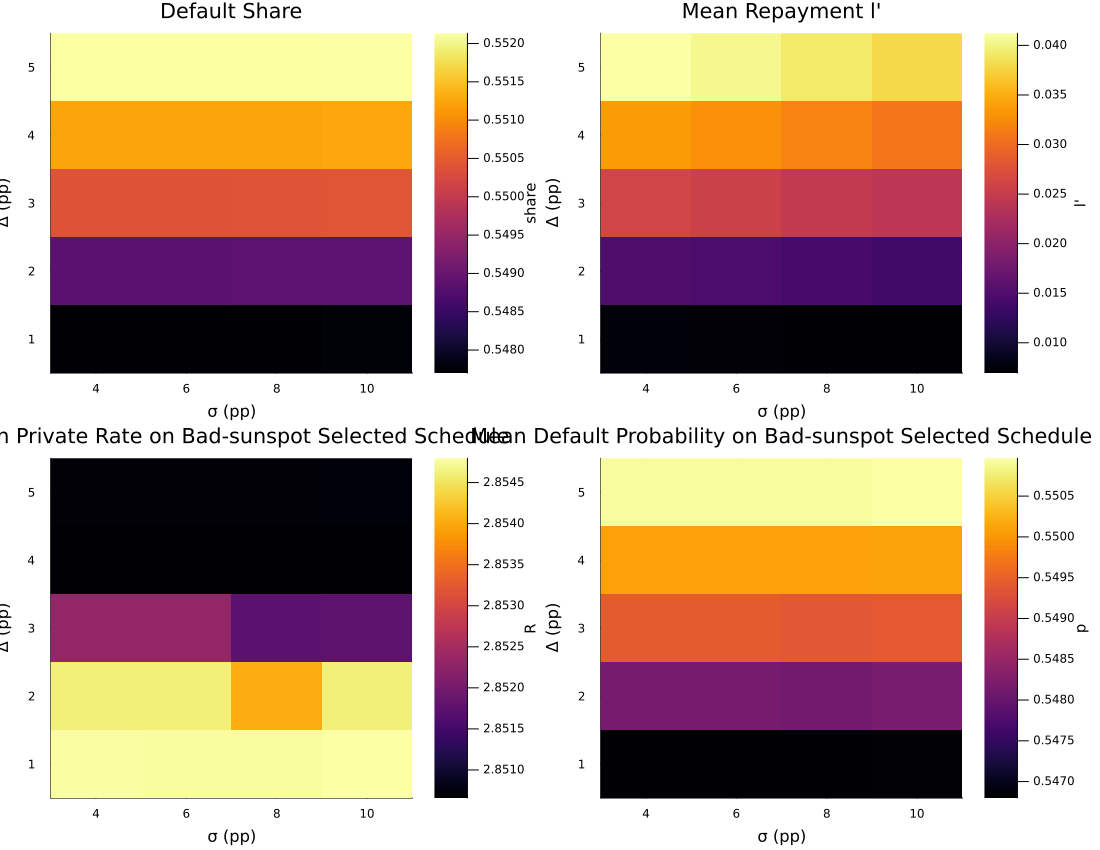

In [ ]:
default_share_mat = metric_matrix(grid_results.summary, :default_share)
mean_l_repay_mat = metric_matrix(grid_results.summary, :mean_l_repay)
mean_R_bad_mat = metric_matrix(grid_results.summary, :mean_R_bad)
mean_p_bad_mat = metric_matrix(grid_results.summary, :mean_p_bad)

x_sigma = 100 .* grid_results.sigma_grid
y_delta = 100 .* grid_results.delta_grid

p1 = heatmap(x_sigma, y_delta, default_share_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Default Share", colorbar_title = "share")
p2 = heatmap(x_sigma, y_delta, mean_l_repay_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Repayment l'", colorbar_title = "l'")
p3 = heatmap(x_sigma, y_delta, mean_R_bad_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Private Rate on Bad-sunspot Selected Schedule", colorbar_title = "R")
p4 = heatmap(x_sigma, y_delta, mean_p_bad_mat, xlabel = "σ (pp)", ylabel = "Δ (pp)", title = "Mean Default Probability on Bad-sunspot Selected Schedule", colorbar_title = "p")

plot(p1, p2, p3, p4, layout = (2, 2), size = (1100, 850))


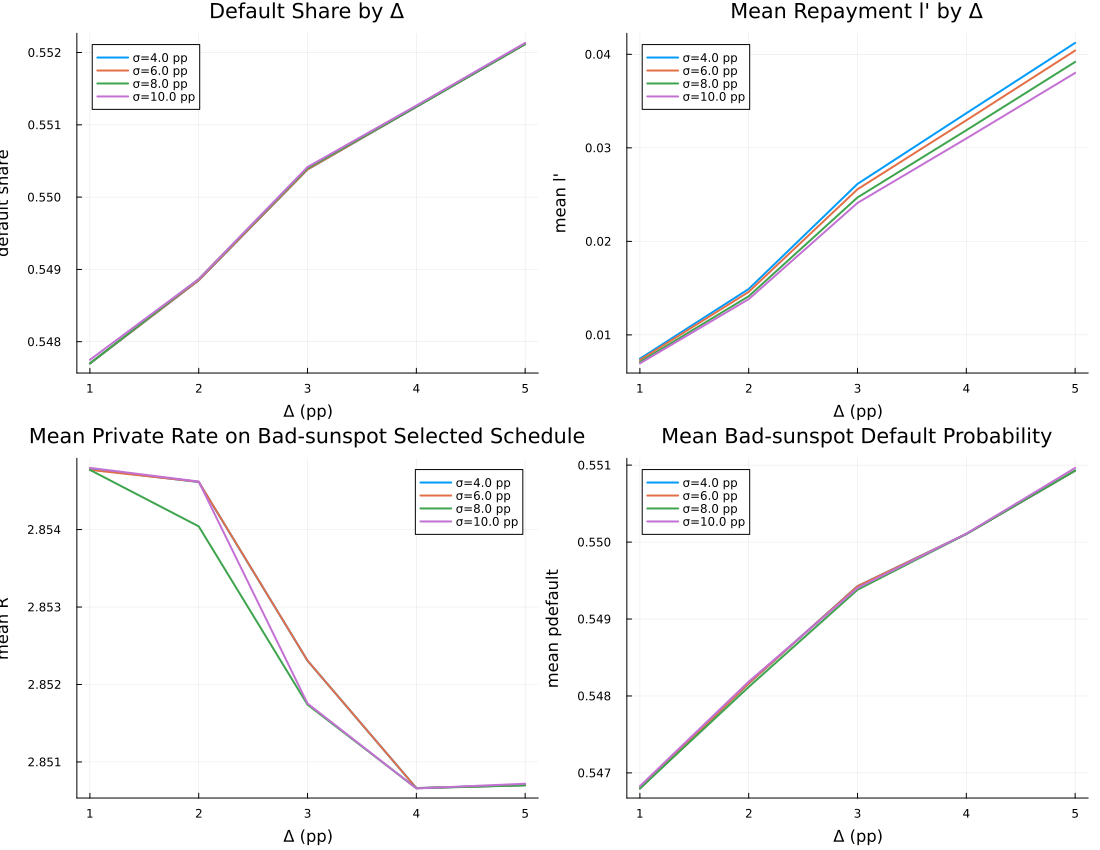

In [33]:
x_delta = 100 .* grid_results.delta_grid

p1 = plot(xlabel = "Δ (pp)", ylabel = "default share", title = "Default Share by Δ")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p1, x_delta, [grid_results.summary[i, j].default_share for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p2 = plot(xlabel = "Δ (pp)", ylabel = "mean l'", title = "Mean Repayment l' by Δ")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p2, x_delta, [grid_results.summary[i, j].mean_l_repay for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p3 = plot(xlabel = "Δ (pp)", ylabel = "mean R", title = "Mean Private Rate on Bad-sunspot Selected Schedule")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p3, x_delta, [grid_results.summary[i, j].mean_R_bad for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

p4 = plot(xlabel = "Δ (pp)", ylabel = "mean pdefault", title = "Mean Bad-sunspot Default Probability")
for (j, σ) in enumerate(grid_results.sigma_grid)
    plot!(p4, x_delta, [grid_results.summary[i, j].mean_p_bad for i in eachindex(grid_results.delta_grid)], label = "σ=$(round(100 * σ, digits = 0)) pp", lw = 2)
end

plot(p1, p2, p3, p4, layout = (2, 2), size = (1100, 850))
